# Binance USDM BTC RSI 30/70 Backtest (Ad Hoc)

Disposable exploratory notebook for a 1-year backtest using:

- Venue: Binance USD-M via `CCXTDataSource`
- Symbol: `BTC/USDT:USDT`
- Timeframe: `1h`
- Range: `2024-01-01 00:00:00 UTC` to `2025-01-01 00:00:00 UTC`
- Strategy: RSI 30/70 market entry/exit


In [1]:
from __future__ import annotations

from datetime import datetime, timezone

import matplotlib.pyplot as plt

from quantleet.backtest import BacktestEngine
from quantleet.data import CCXTDataSource
from quantleet.research import Strategy, qc, ta
from quantleet.trading.domain.costs import CostConfig

In [2]:
class Rsi3070Strategy(Strategy):
    def init(self) -> None:
        self.rsi = ta.rsi(self.data.close, length=14)
        self.in_position = False

    def on_bar(self, bar) -> None:
        if qc.is_na(self.rsi[0]):
            return
        if (not self.in_position) and self.rsi[0] < 30:
            self.buy(quantity=1)
            self.in_position = True
        elif self.in_position and self.rsi[0] > 70:
            self.sell(quantity=1)
            self.in_position = False


start = int(datetime(2024, 1, 1, tzinfo=timezone.utc).timestamp() * 1000)
end = int(datetime(2025, 1, 1, tzinfo=timezone.utc).timestamp() * 1000)

bars = CCXTDataSource(
    exchange="binance",
    market="usdm",
    symbol="BTC/USDT:USDT",
    timeframe="1h",
    start=start,
    end=end,
).load()

engine = BacktestEngine(
    initial_cash=1_000_000.0,
    costs=CostConfig(tick_size=0.1, slippage_ticks=1.0, fee_rate=0.0004),
)

result = engine.run(
    bars=bars,
    strategy=Rsi3070Strategy(),
)

bar_times = [datetime.fromtimestamp(row.timestamp / 1000, tz=timezone.utc) for row in bars.rows]
close_prices = [row.close for row in bars.rows]

buy_trades = [fill for fill in result.trade_log if fill.side == "buy"]
sell_trades = [fill for fill in result.trade_log if fill.side == "sell"]

summary = {
    "bars": len(bars.rows),
    "trades": result.summary.total_trades,
    "return_pct": round(result.summary.total_return * 100, 4),
    "win_rate_pct": round(result.summary.win_rate * 100, 4),
    "max_drawdown_pct": round(result.summary.max_drawdown * 100, 4),
    "profit_factor": result.summary.profit_factor,
    "average_win": round(result.summary.average_win, 4),
    "average_loss": round(result.summary.average_loss, 4),
    "final_equity": round(result.summary.final_equity, 4),
    "realized_pnl": round(result.summary.realized_pnl, 4),
}
summary

{'bars': 8784,
 'trades': 192,
 'return_pct': 0.3845,
 'win_rate_pct': 63.5417,
 'max_drawdown_pct': 2.3258,
 'profit_factor': 1.145976228604,
 'average_win': 1139.1361,
 'average_loss': 1732.4543,
 'final_equity': 1003845.4547,
 'realized_pnl': 8851.4}

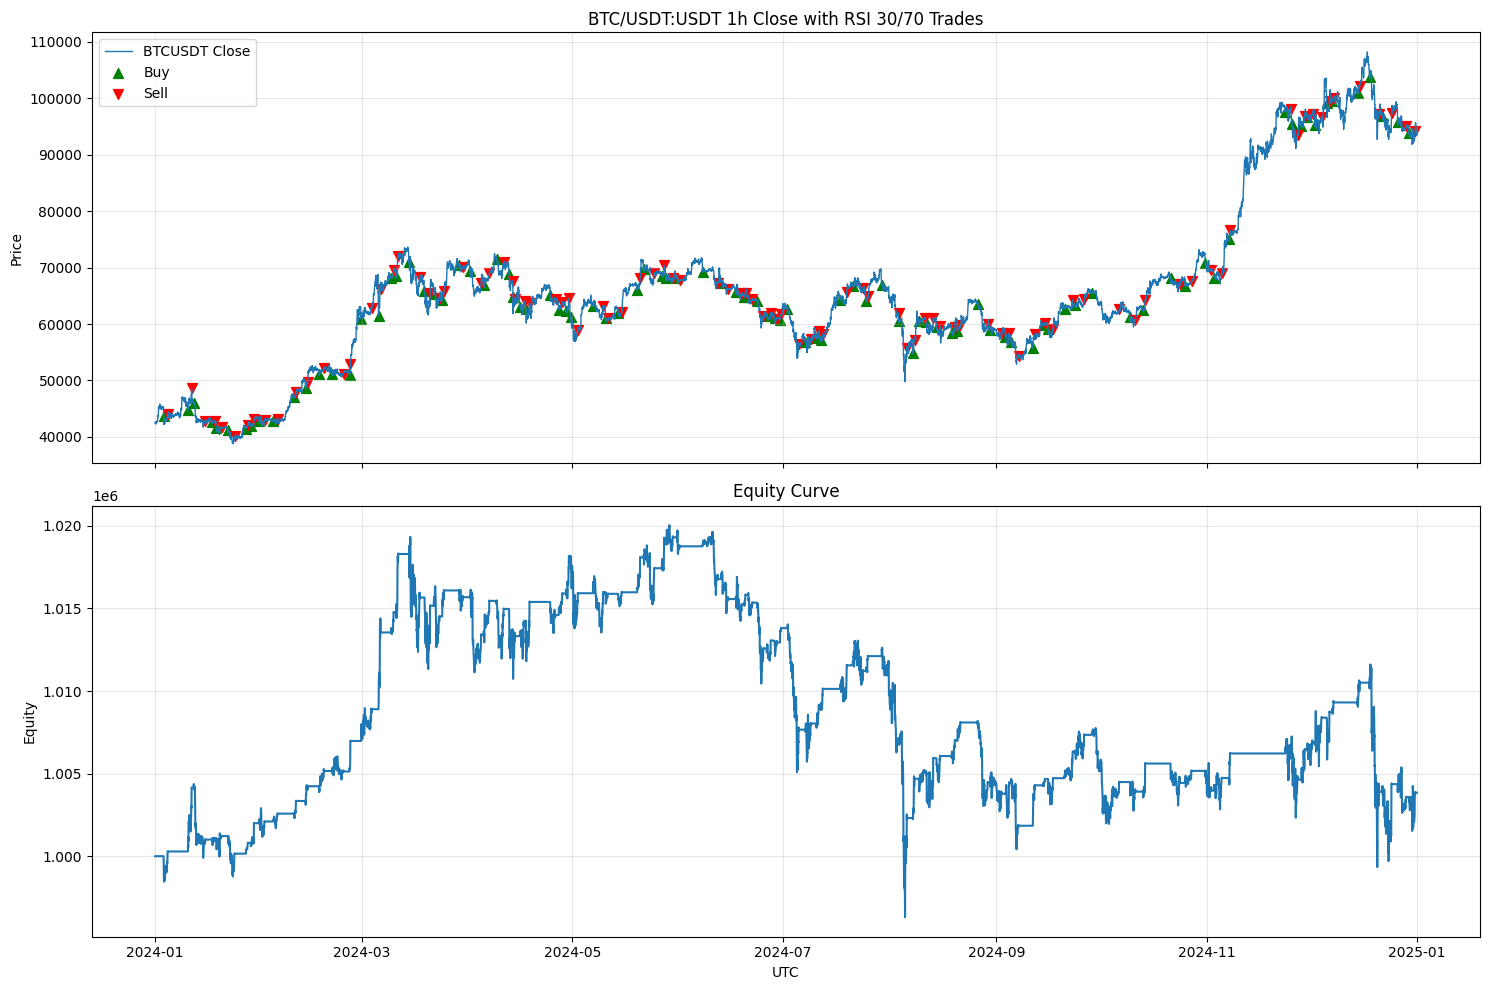

In [3]:
fig, (ax_price, ax_equity) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

ax_price.plot(bar_times, close_prices, label="BTCUSDT Close", linewidth=1.0)
ax_price.scatter(
    [datetime.fromtimestamp(fill.timestamp / 1000, tz=timezone.utc) for fill in buy_trades],
    [fill.price for fill in buy_trades],
    marker="^",
    color="green",
    s=50,
    label="Buy",
)
ax_price.scatter(
    [datetime.fromtimestamp(fill.timestamp / 1000, tz=timezone.utc) for fill in sell_trades],
    [fill.price for fill in sell_trades],
    marker="v",
    color="red",
    s=50,
    label="Sell",
)
ax_price.set_title("BTC/USDT:USDT 1h Close with RSI 30/70 Trades")
ax_price.set_ylabel("Price")
ax_price.legend(loc="upper left")
ax_price.grid(alpha=0.3)

ax_equity.plot(bar_times, result.equity_curve, label="Equity Curve", color="tab:blue")
ax_equity.set_title("Equity Curve")
ax_equity.set_ylabel("Equity")
ax_equity.set_xlabel("UTC")
ax_equity.grid(alpha=0.3)

plt.tight_layout()
plt.show()